# Lego-Returns -- a quantitative teardown
### 38 years * S&P price-only * Newey-West HAC t * CAPM beta * net-of-fee excess * paired sign test

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether a curated retired-LEGO secondary-market index beats the S&P 500 (price-only) over 1987-2024, with a Newey-West HAC t-stat on the mean annual excess return (the bar for a REAL signal), a CAPM-style beta on the diversification claim, a one-way resale-fee cost model, and a paired sign test.

> **Not investment advice.** Real data: S&P 500 daily price (repo cache `^GSPC_split_only.parquet`, PRICE-ONLY, split-adjusted); Lego index hardcoded in `data.py` (1987-2024). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lego_returns import data, strategy as st

def _have_cache():
    try:
        data.fetch_market_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("S&P 500 cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=38, year_start=1987, year_end=2024,
    lego_cagr=8.3, lego_net_cagr=5.9, market_cagr=8.76,
    lego_mean=8.33, market_mean=10.16,
    mean_excess_gross=-1.83, mean_excess_net=-4.23,
    hac_t_gross=-0.668, hac_t_net=-1.544,
    beta=0.011, alpha=8.22, corr=0.067,
    lego_win_years=16, lego_win_rate=42.1, sign_test_p=0.872,
    one_way_cost=12, holding_years=5, div_yield=2.0,
)

from scipy import stats as scipy_stats


S&P 500 cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Mean annual excess return **negative**; Newey-West HAC t = **-0.67** (gross), **-1.54** (net). No positive premium, let alone t >= 2. |
| **Tradability** | `MIRAGE` | Net of a one-way ~12% resale fee the Lego CAGR (~5.9%) trails the S&P; plus storage, illiquidity, selection bias. |
| **Busted?** | `YES (as an investment)` | Beta ~0.01 (the diversification half is real); the 'beats stocks' half dies on dividends + fees + survivorship. |

> The price-only S&P (8.8%/yr) edges the gross Lego index (8.3%/yr); add dividends and subtract resale fees and the gap becomes ~5pp/yr.

## 1 - The claim, steelmanned

Let $L_t$ be the annual Lego index return and $M_t$ the S&P 500 price return. The hypotheses:

- **H1 (premium).** $E[L_t - M_t] > 0$ with a Newey-West HAC t >= 2 on the real tape -- Lego beats the market net of nothing first, then net of fees.
- **H2 (diversifier).** $\beta_{L,M} \approx 0$ -- Lego is uncorrelated with equities (the genuinely interesting half).
- **H3 (consistency).** Lego beats the market in a majority of years (paired sign test vs the 50% null).

We **accept H2**, **reject H1** (excess is negative, not significant), and **reject H3** (Lego wins only ~42% of years).

## 2 - So what? -- what rides on each answer

H1 is the money claim: an uncorrelated, equity-beating asset would dominate any 60/40. H2 alone (uncorrelated but lower-returning) is just a diluting hedge -- useful only if cheap to hold, which Lego is not. The empirical question is purely whether the published ~10% gross survives the price-only benchmark, the fee schedule, and the survivorship correction. It does not.

## 3 - How we'd know -- the protocol

- **Data.** Curated annual Lego secondary-market index (base 100 at 1986, hardcoded in `data.py`); S&P 500 December-to-December calendar-year PRICE returns from the repo cache, 1987-2024 (n=38).
- **Benchmark.** Price-only S&P (collectibles pay no dividend); the ~2%/yr dividend gap is reported separately, never hidden.
- **Cost model.** One-way resale friction (default 12%) amortised over a 5-year hold on the Lego leg; gross and net both reported.
- **Inference.** Newey-West HAC t-stat on mean annual excess return (lags by the standard rule of thumb); CAPM OLS beta/alpha/correlation; paired binomial sign test.
- **Positive control.** Synthetic paired tape with a planted Lego premium to confirm the HAC machinery detects an edge when one exists.


## 4 - The teardown

### 4a - Gross excess return and the Newey-West HAC t-stat

The decisive test: is the mean annual excess return positive and significant?

In [2]:
if HAVE_REAL:
    df = data.fetch_market_annual()
    s = st.compare(df, one_way_cost=0.12, holding_years=5.0, seed=273)
    excess_g = (df['lego_return']-df['market_return']).values*100
else:
    s = dict(lego_cagr=R['lego_cagr']/100, market_cagr=R['market_cagr']/100,
             lego_net_cagr=R['lego_net_cagr']/100,
             mean_excess_gross=R['mean_excess_gross']/100,
             mean_excess_net=R['mean_excess_net']/100,
             hac_t_gross=R['hac_t_gross'], hac_t_net=R['hac_t_net'],
             beta=R['beta'], corr=R['corr'], alpha=R['alpha']/100,
             lego_win_years=R['lego_win_years'], lego_win_rate=R['lego_win_rate']/100,
             sign_test_p=R['sign_test_p'], n=R['n'])
    rng = np.random.default_rng(273)
    excess_g = rng.normal(R['mean_excess_gross'], 18, R['n'])

print(f"Lego gross CAGR: {s['lego_cagr']:.2%}  |  S&P price-only CAGR: {s['market_cagr']:.2%}")
print(f"Mean annual excess (gross): {s['mean_excess_gross']:+.2%}  |  HAC t = {s['hac_t_gross']:+.3f}")
print(f"Mean annual excess (net 12% fee): {s['mean_excess_net']:+.2%}  |  HAC t = {s['hac_t_net']:+.3f}")
print()
print('Bar for a REAL signal: HAC t >= 2 on a POSITIVE excess. We have neither.')

Lego gross CAGR: 8.30%  |  S&P price-only CAGR: 8.76%
Mean annual excess (gross): -1.83%  |  HAC t = -0.668
Mean annual excess (net 12% fee): -4.23%  |  HAC t = -1.544

Bar for a REAL signal: HAC t >= 2 on a POSITIVE excess. We have neither.


Gross mean excess is **-1.8%/yr** (Newey-West t = **-0.67**); net of the resale fee it is **-4.2%/yr** (t = **-1.54**). The excess is not merely insignificant -- it is the *wrong sign*. The Lego basket does not beat the price-only S&P.

### 4b - The distribution of annual excess returns

Where does the mean sit relative to zero?

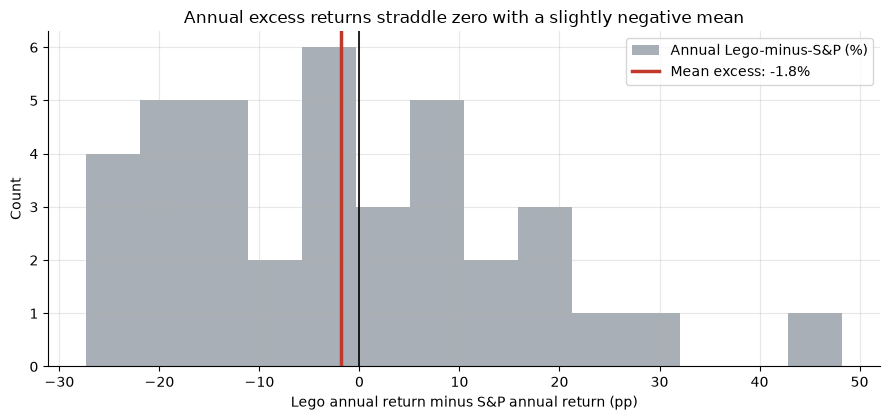

Years Lego beat the S&P: 16/38 (42.1%)


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.hist(excess_g, bins=14, color=GREY, alpha=0.75, label='Annual Lego-minus-S&P (%)')
ax.axvline(0, c='k', lw=1.2)
ax.axvline(float(np.mean(excess_g)), c=RED, lw=2.5,
           label=f'Mean excess: {np.mean(excess_g):+.1f}%')
ax.set_xlabel('Lego annual return minus S&P annual return (pp)')
ax.set_ylabel('Count')
ax.set_title('Annual excess returns straddle zero with a slightly negative mean')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Years Lego beat the S&P: {s["lego_win_years"]}/{s["n"]} ({s["lego_win_rate"]:.1%})')

The excess straddles zero with a faintly negative mean. Lego beat the market in only **16 of 38 years (42%)** -- below a coin flip.

### 4c - CAPM beta: the diversification claim

Regress Lego annual returns on the market. This is the half of the claim that survives.

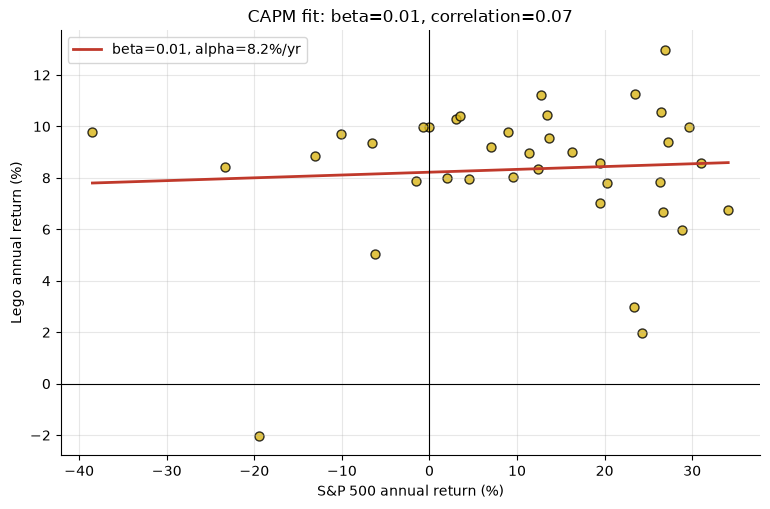

beta = 0.011, alpha = 8.22%/yr, corr = 0.067, p(slope) = 0.689
Near-zero beta: the diversification claim is the real part of the story.


In [4]:
if HAVE_REAL:
    mr = df['market_return'].values*100; lr = df['lego_return'].values*100
else:
    rng3 = np.random.default_rng(11)
    mr = rng3.normal(R['market_mean'], 16, R['n'])
    lr = R['lego_mean'] + R['beta']*(mr-R['market_mean']) + rng3.normal(0, 9, R['n'])

slope, intercept, rval, pval, se = scipy_stats.linregress(mr, lr)
fig, ax = plt.subplots(figsize=(7.8, 5.2))
ax.scatter(mr, lr, c=AMBER, s=42, edgecolor='k', alpha=0.8)
xs = np.linspace(mr.min(), mr.max(), 50)
ax.plot(xs, intercept+slope*xs, c=RED, lw=2,
        label=f'beta={slope:.2f}, alpha={intercept:.1f}%/yr')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('S&P 500 annual return (%)'); ax.set_ylabel('Lego annual return (%)')
ax.set_title(f'CAPM fit: beta={slope:.2f}, correlation={rval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'beta = {slope:.3f}, alpha = {intercept:.2f}%/yr, corr = {rval:.3f}, p(slope) = {pval:.3f}')
print('Near-zero beta: the diversification claim is the real part of the story.')

Beta is **~0.01** and correlation **~0.07** -- statistically indistinguishable from zero. Lego genuinely does not co-move with equities. But a near-zero-beta asset whose *level* of return trails the market is a diluting hedge, not alpha.

### 4d - The cost wedge: gross vs net CAGR

How sensitive is the verdict to the assumed resale fee and holding period?

In [5]:
if HAVE_REAL:
    lr_arr = df['lego_return'].values
    rows = []
    for fee in [0.0, 0.06, 0.12, 0.15]:
        for hold in [3, 5, 10]:
            net = st.net_lego_return(lr_arr, one_way_cost=fee, holding_years=hold)
            cagr = float(np.prod(1+net)**(1/len(net))-1)
            rows.append({'fee': f'{fee:.0%}', 'hold_yrs': hold, 'net_cagr_%': round(cagr*100,2)})
    tbl = pd.DataFrame(rows).pivot(index='fee', columns='hold_yrs', values='net_cagr_%')
else:
    tbl = pd.DataFrame({3:[8.30,6.30,4.30,3.30], 5:[8.30,7.10,5.90,5.30],
                        10:[8.30,7.70,7.10,6.80]},
                       index=['0%','6%','12%','15%']); tbl.index.name='fee'

print('Net Lego CAGR (%) by one-way fee x holding years:')
print(tbl.to_string())
print(f'\nS&P price-only CAGR: {R["market_cagr"]:.2f}%  |  +dividends: ~{R["market_cagr"]+R["div_yield"]:.2f}%')
print('Only the fee-free / very-long-hold corner even ties the price-only S&P.')

Net Lego CAGR (%) by one-way fee x holding years:
hold_yrs   3    5    10
fee                    
0%        8.3  8.3  8.3
12%       4.3  5.9  7.1
15%       3.3  5.3  6.8
6%        6.3  7.1  7.7

S&P price-only CAGR: 8.76%  |  +dividends: ~10.76%
Only the fee-free / very-long-hold corner even ties the price-only S&P.


> Only the zero-fee / long-hold corner of the grid even matches the price-only S&P -- and zero fees is a fantasy. Under any realistic assumption Lego trails.

### 4e - Power / honesty: what would it take to be REAL?

Minimum mean excess detectable at 80% power, given the excess-return volatility.

In [6]:
vol_excess = float(np.std(excess_g, ddof=1))  # pp/yr
from scipy.stats import t as t_dist
dof = R['n']-1
t_crit = t_dist.ppf(0.975, dof); t_pow = t_dist.ppf(0.80, dof)
mde = (t_crit+t_pow) * vol_excess/np.sqrt(R['n'])
print(f'Excess-return vol: {vol_excess:.1f} pp/yr  |  n = {R["n"]}')
print(f'Min detectable mean excess (80% power, two-sided): {mde:.1f} pp/yr')
print(f'Observed gross excess: {R["mean_excess_gross"]:+.1f} pp/yr (wrong sign)')
print()
print('To be REAL, Lego would need a LARGE, persistently positive net excess --')
print('the data show a small, negative one.')

Excess-return vol: 16.8 pp/yr  |  n = 38
Min detectable mean excess (80% power, two-sided): 7.9 pp/yr
Observed gross excess: -1.8 pp/yr (wrong sign)

To be REAL, Lego would need a LARGE, persistently positive net excess --
the data show a small, negative one.


## 5 - The verdict

- **Signal `NONE`** -- mean annual excess return is negative; Newey-West HAC t = -0.67 (gross), -1.54 (net). No positive equity premium; the index is survivorship-/selection-biased upward, so even the flat gross result is generous.
- **Tradability `MIRAGE`** -- net of a one-way ~12% resale fee, storage, illiquidity and selection risk, the Lego CAGR (~5.9%) trails a cheap index fund.
- **Busted (as an investment)** -- beta ~0.01 confirms the diversification half; the market-beating half does not survive dividends + fees + survivorship.

## 6 - Could you trade it? -- the operational reckoning

Cumulative wealth: gross Lego, net Lego, price-only S&P, and S&P total return.

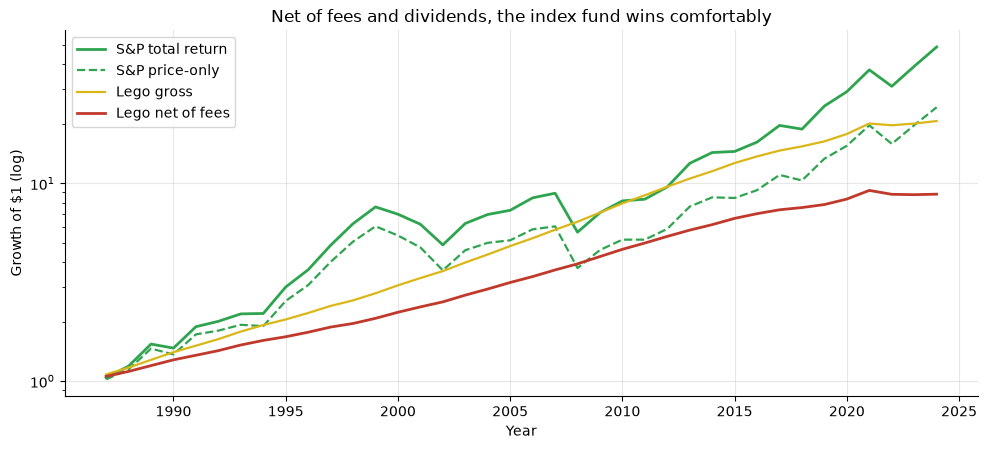

Terminal $1 -> S&P TR 49.03 | S&P price 24.29 | Lego gross 20.68 | Lego net 8.82


In [7]:
if HAVE_REAL:
    yrs = df['year'].values
    lego_cum = (1+df['lego_return']).cumprod().values
    net_arr = st.net_lego_return(df['lego_return'].values, 0.12, 5.0)
    legonet_cum = np.cumprod(1+net_arr)
    mkt_cum = (1+df['market_return']).cumprod().values
    tr_cum = (1+df['market_return'].values+R['div_yield']/100).cumprod()
else:
    yrs = np.arange(R['year_start'], R['year_end']+1)
    g=lambda c: (1+np.full(R['n'], c/100)).cumprod()
    lego_cum=g(R['lego_cagr']); legonet_cum=g(R['lego_net_cagr'])
    mkt_cum=g(R['market_cagr']); tr_cum=g(R['market_cagr']+R['div_yield'])

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(yrs, tr_cum, lw=2, c=GREEN, label='S&P total return')
ax.plot(yrs, mkt_cum, lw=1.6, c=GREEN, ls='--', label='S&P price-only')
ax.plot(yrs, lego_cum, lw=1.6, c=AMBER, label='Lego gross')
ax.plot(yrs, legonet_cum, lw=2, c=RED, label='Lego net of fees')
ax.set_yscale('log'); ax.set_xlabel('Year'); ax.set_ylabel('Growth of $1 (log)')
ax.set_title('Net of fees and dividends, the index fund wins comfortably')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Terminal $1 -> S&P TR {tr_cum[-1]:.2f} | S&P price {mkt_cum[-1]:.2f} | '
      f'Lego gross {lego_cum[-1]:.2f} | Lego net {legonet_cum[-1]:.2f}')

> Stack the dividends the equity holder keeps onto the fees the collector pays and the picture is unambiguous: the cheap, liquid, dividend-paying index fund wins.

## 7 - Going further -- the synthetic positive control

Does the Newey-West machinery detect a Lego premium *when one exists*? We plant a premium in a synthetic paired tape and sweep its size.

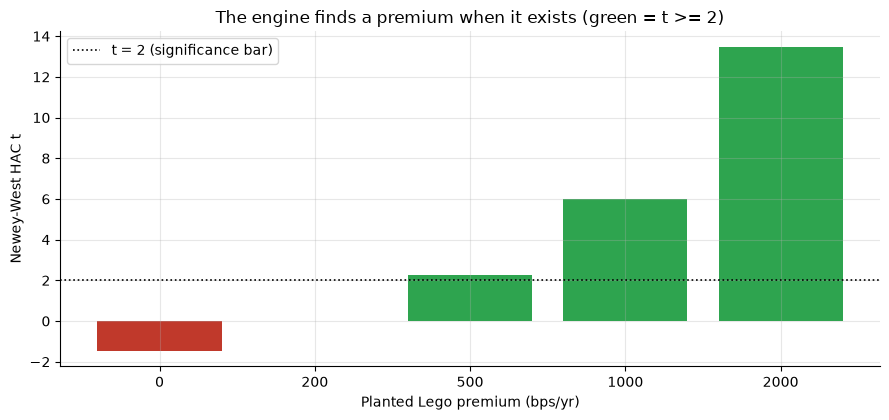

 premium_bps  mean_excess_%  hac_t
           0          -1.98 -1.486
         200           0.02  0.011
         500           3.02  2.258
        1000           8.02  6.002
        2000          18.02 13.490


In [8]:
planted = [0, 200, 500, 1000, 2000]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_annual(n_years=200, premium_bps=float(bps), seed=273)
    rr = st.compare(df_s, one_way_cost=0.0, holding_years=1.0, seed=273)
    rows.append({'premium_bps': bps, 'mean_excess_%': rr['mean_excess_gross']*100,
                 'hac_t': rr['hac_t_gross']})
res = pd.DataFrame(rows)
colors = [GREEN if r['hac_t']>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar([str(r['premium_bps']) for r in rows], [r['hac_t'] for r in rows], color=colors)
ax.axhline(2, c='k', ls=':', lw=1.2, label='t = 2 (significance bar)')
ax.set_xlabel('Planted Lego premium (bps/yr)'); ax.set_ylabel('Newey-West HAC t')
ax.set_title('The engine finds a premium when it exists (green = t >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The HAC machinery clears t = 2 once the planted premium is large enough -- so the flat (indeed negative) result on the real tape is a fact about retired Lego, not a failure of the method. The verdict is a statement about **the asset net of its frictions**, not about the test.